In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [100]:
import pandas as pd #파일입력(read_excel), 교차표(crosstab), 원핫인코딩(get_dummies)
import numpy as np
from sklearn.model_selection import train_test_split # 훈련셋과 시험셋 분리함수
from tensorflow.keras.utils import to_categorical #원핫인코딩
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from tensorflow.keras.models import Sequential, save_model,load_model
# 과적합을 줄이기 위한 방법 : dropout, 배치정규화, L2정규화
from tensorflow.keras.layers import Dense,Input,Dropout, BatchNormalization # dropout은 과적합을 줄이기 위한 방법
from tensorflow.keras.regularizers import l2
# 데이터 불균형 극복 5.5 : 4.5 => 5:5
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt # 모델 학습과정 살펴보기
from sklearn.metrics import confusion_matrix # 혼동행렬

age: 나이 (년 단위)
sex: 성별 (1 = 남성, 0 = 여성)
cp (Chest Pain Type): 흉통의 유형 (0~3 값, 일반 협심증부터 무증상까지 분류)
trestbps: 안정 시 혈압 (mmHg)
chol: 혈청 콜레스테롤 수치 (mg/dl)
fbs (Fasting Blood Sugar): 공복 혈당이 120 mg/dl 초과인지 여부 (1 = 참, 0 = 거짓)
restecg: 안정 시 심전도(ECG) 결과 (0~2)
thalach: 운동 시 달성한 최대 심박수
exang: 운동 유발 협심증 여부 (1 = 있음, 0 = 없음)
oldpeak: 휴식기에 비해 운동 시 나타나는 ST 부위 하강(ST depression) 정도
slope: 최고 운동 시 ST 세그먼트의 기울기ca: 형광투시법으로 색칠된 주요 혈관 수 (0~3개)
thal: 지중해빈혈 등 혈액 질환 여부 (정상, 고정 결함, 가역적 결함 등)
target (Diagnosis): 심장질환 진단 결과 (0 = 정상, 1 = 심장질환 있음)

# 이진분류(로지스틱 회귀분석 )
- 1. 데이터셋 생성 & 전처리
    * 엑셀 -> 데이터프래임 ->?처리(결측치로 전환하여 결측치 처리)-> X,y분리
        -> X변수의 scale조정 -> train_test_split()을 이용하여 학습셋과 테스트셋을 분리
- 2. 모델생성(입력13,타겟1) -과적합 고려 & 학습과정 설정 & 학습
- 3. 모델평가(그래프, 평가, 혼동행렬=교차그래프)
- 4. 모델사용

## 1. 데이터셋  생성 & 전처리

In [101]:
df=pd.read_excel('data/heart-disease.xlsx'
             #sheet_name='processed.cleveland'
             )
df.head()

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [4]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [5]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [102]:
df[(df['chol']=='?') |(df['ca']=='?') | (df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [103]:
# 방법1 : ?가있는 행을 삭제
drop_idx = df[(df['chol']=='?') |(df['ca']=='?') | (df['hsl']=='?')].index #삭제할 행
df.drop(drop_idx)

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1


In [107]:
# 방법2 : ?를 결측치로 대체 => 결측치 삭제
df=df.replace('?',np.nan)
df[(df['chol']=='?') |(df['ca']=='?') | (df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [108]:
# 결측치가 포함된 데이터 추출
df[df['chol'].isna() | df['ca'].isna() | df['hsl'].isna()]
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
87,53,0,3,128,216.0,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223.0,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247.0,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204.0,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220.0,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175.0,0,0,173,0,0.0,1,NaN,3.0,0


In [109]:
# 결측치 처리 : 삭제(dropna) cf.fillna() apply()
df.dropna(how='any',inplace=True) #결측치가 한열이라도 있으면 삭제
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [110]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [111]:
df.shape

(296, 14)

In [112]:
df['heartDisease'].value_counts()/df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [113]:
#  타겟변수 분포가 균형적인지
df['heartDisease'].value_counts(normalize=True)

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [114]:
# X,y분리 -> X변수의 scale조정 
X = df.iloc[:,:-1].values # 맨마지막 열을 제외한 부분을 numpy배열
y = df.iloc[:,-1:].to_numpy() # 2차원 numpy 배열
X.shape, y.shape

((296, 13), (296, 1))

In [115]:
# X변수의 scale 2조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
print('원 데이터:', X[0])
print('스케일 조정 데이터:',scaled_X[0])

원 데이터: [ 63.    1.    1.  145.  233.    1.    2.  150.    0.    2.3   3.    0.
   6. ]
스케일 조정 데이터: [0.70833333 1.         0.         0.48113208 0.24429224 1.
 1.         0.60305344 0.         0.37096774 1.         0.
 0.75      ]


In [116]:
# scaled_X와 y를 학습데이터셋 : 테스트셋 = 8:2
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                                y,
                                                 #train_size=0.8,    
                                                test_size=0.2,
                                                random_state=7,
                                                stratify=y)# 층화추출

In [117]:
# 심장병 음성/양성 비율(y,y_train,y_test)
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


In [118]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 13), (236, 1), (60, 13), (60, 1))

## 2.모델생성 &학습과정 설정 &학습
- 모델 : 13=> 32=> 16=> 8=> 1
- 학습과정을 시각화한 그래프를 보고 과적합 줄이기
- 과적합 줄이기 위한 방법
    * dropout : 학습할 때마다 일부 뉴런을 랜덤하게 끄기, 특정 뉴런 조합에 과하게 의존하는것을 막아줘.
    * BatchNormalization(배치 정규화) : 각 층의 출력을 정규화해서 더 안정적이고 빠르게 수렴하도록 도와줌
    * L2 정규화 : 가중치가 너무 커지지않게 학습과정에서 미리 누름.가중치가 크면 입력값이 살짝 바뀌어도 출력이 확 바뀜.
        규제를 세게(0.01) / 규제 중간(0.001) / 규제 약하게(0.0001)

In [119]:
from tensorflow.keras.layers import BatchNormalization # dropout은 과적합을 줄이기 위한 방법
from tensorflow.keras.regularizers import l2
model = Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu',
               kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화
model.add(Dropout(0.4))         # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
# Dense층 뒤에 배치정규화에서의 파라미터 : Dense층 출력갯수 * 4
    # ggamma(스캐일) - 32(학습됨)
    # beta(이동)     - 32(학습됨)
    # moving_mean(이동평균) - 32 (학습안됨)
    # moving_variance(이동분산) - 32 (학습안됨)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_20 (Bat  (None, 32)               128       
 chNormalization)                                                
                                                                 
 dropout_20 (Dropout)        (None, 32)                0         
                                                                 
 dense_31 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_21 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_21 (Dropout)        (None, 16)                0

In [120]:
# 학습과정 설정
from tensorflow.keras.metrics import Recall,Precision,Accuracy
from tensorflow.keras.optimizers import Adam
model.compile(loss = 'binary_crossentropy',
             optimizer = 'adam',
             metrics = ['accuracy',#Accuracy(name='accuracy')
                        Recall(name='recall'),        # 재현을(실제값 중심=1을 얼마나 잘 예측했는지)
                        Precision(name='precision')]) # 정밀도(예측값 중심=1 이라고 예측한것중 얼마나)

In [121]:
# 클래스(0/1) 가중치 계산(55:45 정도의 비율 => 50:50)
from sklearn.utils.class_weight import compute_class_weight
y_train_flat = y_train.flatten()
class_weight = compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_train_flat),
                y=y_train_flat)
print('class_weight:',class_weight)
class_weight_dict = dict(enumerate(class_weight))
print('학습시 가중치 조정값:',class_weight_dict)
# y_train의 빈도수(0은?개, 1은?개)
values,counts = np.unique(y_train_flat, return_counts=True)
print('반도수:',dict(zip(values,counts)))
print(counts[0]*class_weight_dict[0],counts[1]*class_weight_dict[1])
#빈도 분포
ratios = counts / counts.sum()
print(ratios[0]*class_weight_dict[0],ratios[1]*class_weight_dict[1])

class_weight: [0.921875   1.09259259]
학습시 가중치 조정값: {0: 0.921875, 1: 1.0925925925925926}
반도수: {0: 128, 1: 108}
118.0 118.0
0.5 0.5


In [122]:
# callback설정
# ReduceLROnPlateau : 성능이 정체되면 학습률(Learnig_rate)을 낮춰서 세밀하게 탐색
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5, #학습률을 원학습률의 절반으로
                              patience=7, #7번 연속 개선이 없으면 
                              min_lr=1e-6 #학습률의 최소값10의 -6승이하로는 안내려가게
                             )

In [123]:
# 학습
hist = model.fit(X_train,y_train,
                 epochs=200,                
                 validation_split=0.2, # 학습데이터에서 20%를 검증데이터로사용 
                 class_weight=class_weight_dict, # loss계산시 얼마나 더 중요하게 취급될지의 가중치 
                 callbacks=[reduce_lr],
                 verbose=2)

Epoch 1/200
6/6 - 3s - loss: 0.8924 - accuracy: 0.4574 - recall: 0.3908 - precision: 0.4096 - val_loss: 0.7406 - val_accuracy: 0.4167 - val_recall: 0.4286 - val_precision: 0.3600 - lr: 0.0010 - 3s/epoch - 515ms/step
Epoch 2/200
6/6 - 0s - loss: 0.8076 - accuracy: 0.5106 - recall: 0.4713 - precision: 0.4713 - val_loss: 0.7389 - val_accuracy: 0.4583 - val_recall: 0.4286 - val_precision: 0.3913 - lr: 0.0010 - 58ms/epoch - 10ms/step
Epoch 3/200
6/6 - 0s - loss: 0.8586 - accuracy: 0.4840 - recall: 0.4253 - precision: 0.4405 - val_loss: 0.7350 - val_accuracy: 0.5208 - val_recall: 0.4286 - val_precision: 0.4500 - lr: 0.0010 - 66ms/epoch - 11ms/step
Epoch 4/200
6/6 - 0s - loss: 0.8135 - accuracy: 0.5585 - recall: 0.5287 - precision: 0.5227 - val_loss: 0.7302 - val_accuracy: 0.5833 - val_recall: 0.5238 - val_precision: 0.5238 - lr: 0.0010 - 63ms/epoch - 11ms/step
Epoch 5/200
6/6 - 0s - loss: 0.7867 - accuracy: 0.5479 - recall: 0.5747 - precision: 0.5102 - val_loss: 0.7254 - val_accuracy: 0.6250

Epoch 39/200
6/6 - 0s - loss: 0.5728 - accuracy: 0.7660 - recall: 0.7701 - precision: 0.7363 - val_loss: 0.5302 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 0.0010 - 60ms/epoch - 10ms/step
Epoch 40/200
6/6 - 0s - loss: 0.5568 - accuracy: 0.7766 - recall: 0.7701 - precision: 0.7528 - val_loss: 0.5274 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 0.0010 - 61ms/epoch - 10ms/step
Epoch 41/200
6/6 - 0s - loss: 0.5460 - accuracy: 0.7606 - recall: 0.7471 - precision: 0.7386 - val_loss: 0.5260 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 0.0010 - 60ms/epoch - 10ms/step
Epoch 42/200
6/6 - 0s - loss: 0.5646 - accuracy: 0.6968 - recall: 0.6782 - precision: 0.6705 - val_loss: 0.5251 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 0.0010 - 59ms/epoch - 10ms/step
Epoch 43/200
6/6 - 0s - loss: 0.5458 - accuracy: 0.7340 - recall: 0.7931 - precision: 0.6832 - val_loss: 0.5236 - val_accuracy: 

Epoch 77/200
6/6 - 0s - loss: 0.5170 - accuracy: 0.7819 - recall: 0.7701 - precision: 0.7614 - val_loss: 0.4891 - val_accuracy: 0.8125 - val_recall: 0.7619 - val_precision: 0.8000 - lr: 5.0000e-04 - 56ms/epoch - 9ms/step
Epoch 78/200
6/6 - 0s - loss: 0.4676 - accuracy: 0.8191 - recall: 0.8046 - precision: 0.8046 - val_loss: 0.4882 - val_accuracy: 0.8125 - val_recall: 0.7619 - val_precision: 0.8000 - lr: 5.0000e-04 - 62ms/epoch - 10ms/step
Epoch 79/200
6/6 - 0s - loss: 0.4916 - accuracy: 0.7926 - recall: 0.7471 - precision: 0.7927 - val_loss: 0.4881 - val_accuracy: 0.8125 - val_recall: 0.7619 - val_precision: 0.8000 - lr: 5.0000e-04 - 59ms/epoch - 10ms/step
Epoch 80/200
6/6 - 0s - loss: 0.5039 - accuracy: 0.7979 - recall: 0.7816 - precision: 0.7816 - val_loss: 0.4885 - val_accuracy: 0.8125 - val_recall: 0.7619 - val_precision: 0.8000 - lr: 5.0000e-04 - 81ms/epoch - 13ms/step
Epoch 81/200
6/6 - 0s - loss: 0.5271 - accuracy: 0.7872 - recall: 0.7931 - precision: 0.7582 - val_loss: 0.4883 -

Epoch 114/200
6/6 - 0s - loss: 0.4951 - accuracy: 0.7872 - recall: 0.7931 - precision: 0.7582 - val_loss: 0.4955 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.5625e-05 - 61ms/epoch - 10ms/step
Epoch 115/200
6/6 - 0s - loss: 0.4609 - accuracy: 0.7819 - recall: 0.8046 - precision: 0.7447 - val_loss: 0.4959 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.5625e-05 - 59ms/epoch - 10ms/step
Epoch 116/200
6/6 - 0s - loss: 0.4732 - accuracy: 0.7926 - recall: 0.8046 - precision: 0.7609 - val_loss: 0.4960 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.5625e-05 - 57ms/epoch - 9ms/step
Epoch 117/200
6/6 - 0s - loss: 0.4731 - accuracy: 0.8298 - recall: 0.8276 - precision: 0.8090 - val_loss: 0.4964 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.5625e-05 - 57ms/epoch - 10ms/step
Epoch 118/200
6/6 - 0s - loss: 0.4906 - accuracy: 0.7979 - recall: 0.8046 - precision: 0.7692 - val_loss: 0.4

Epoch 151/200
6/6 - 0s - loss: 0.4523 - accuracy: 0.8085 - recall: 0.8161 - precision: 0.7802 - val_loss: 0.4959 - val_accuracy: 0.8125 - val_recall: 0.7619 - val_precision: 0.8000 - lr: 1.0000e-06 - 61ms/epoch - 10ms/step
Epoch 152/200
6/6 - 0s - loss: 0.4869 - accuracy: 0.8032 - recall: 0.8161 - precision: 0.7717 - val_loss: 0.4962 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 57ms/epoch - 10ms/step
Epoch 153/200
6/6 - 0s - loss: 0.4951 - accuracy: 0.8032 - recall: 0.8046 - precision: 0.7778 - val_loss: 0.4966 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 87ms/epoch - 14ms/step
Epoch 154/200
6/6 - 0s - loss: 0.5143 - accuracy: 0.7926 - recall: 0.7816 - precision: 0.7727 - val_loss: 0.4965 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 59ms/epoch - 10ms/step
Epoch 155/200
6/6 - 0s - loss: 0.5032 - accuracy: 0.8138 - recall: 0.8391 - precision: 0.7766 - val_loss: 0.

Epoch 188/200
6/6 - 0s - loss: 0.4789 - accuracy: 0.7979 - recall: 0.8161 - precision: 0.7634 - val_loss: 0.4958 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 62ms/epoch - 10ms/step
Epoch 189/200
6/6 - 0s - loss: 0.4876 - accuracy: 0.8191 - recall: 0.8621 - precision: 0.7732 - val_loss: 0.4958 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 60ms/epoch - 10ms/step
Epoch 190/200
6/6 - 0s - loss: 0.4514 - accuracy: 0.8085 - recall: 0.8161 - precision: 0.7802 - val_loss: 0.4959 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 67ms/epoch - 11ms/step
Epoch 191/200
6/6 - 0s - loss: 0.4974 - accuracy: 0.8085 - recall: 0.8391 - precision: 0.7684 - val_loss: 0.4960 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 1.0000e-06 - 63ms/epoch - 11ms/step
Epoch 192/200
6/6 - 0s - loss: 0.4806 - accuracy: 0.7979 - recall: 0.8046 - precision: 0.7692 - val_loss: 0.

## 3. 모델평가 (그래프,평가,교차표)

In [124]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision', 'lr'])

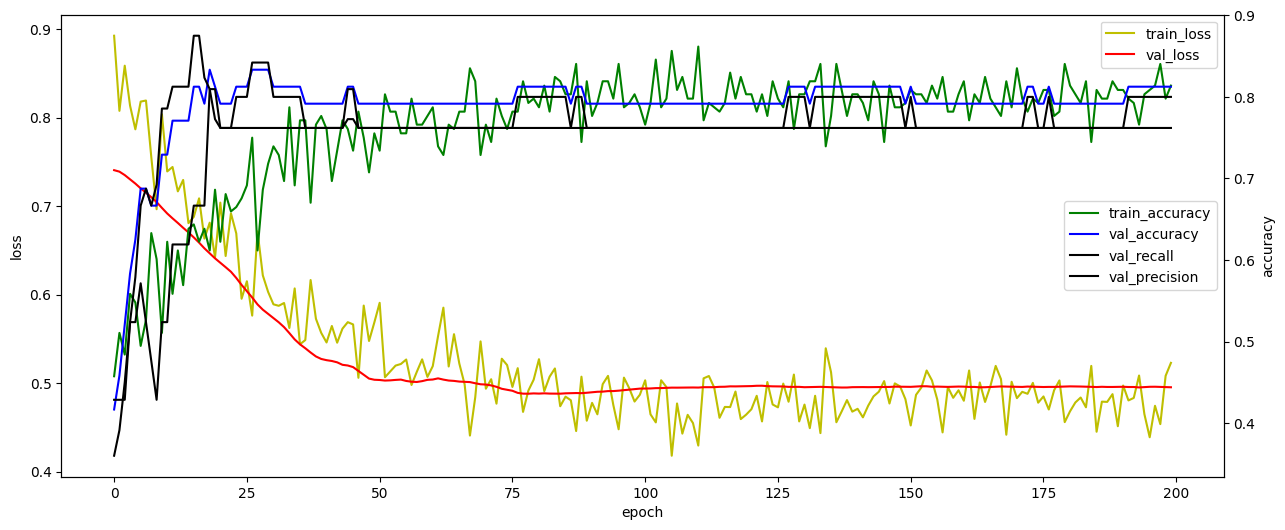

In [125]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')
acc_ax.plot(hist.history['val_precision'],'k',label='val_precision')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

In [126]:
# 평가
score = model.evaluate(X_test,y_test,verbose=0)
print(f'model loss : {score[0]}')
print(f'model accuracy : {score[1]*100:.2f}%')
print(f'model recall : {score[2]*100:.2f}%')
print(f'model precision : {score[3]*100:.2f}%')


model loss : 0.44241446256637573
model accuracy : 83.33%
model recall : 85.71%
model precision : 80.00%


In [127]:
# 교차표(혼동행렬)
# 교차표에서의 실제값 : y_test.reshape(-1)
y_hat=(model.predict(X_test)>0.5).astype(int).reshape(-1) # 예측값을 1차원
                            # 0과1의 기준값 0.5를 이동하면 recall과 precision이 바뀜
                            # 0.5 -> 0.3 recall이 좋아짐(비추)
                            # 0.5 -> 0.7 precision이 좋아짐(비추)

2/2 [==============================] - 0s 4ms/step


In [128]:
pd.crosstab(y_test.reshape(-1),
           y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

예측값,0,1
실제값,,
0,26,6
1,4,24


In [129]:
confusion_matrix(y_test, y_hat)

array([[26,  6],
       [ 4, 24]], dtype=int64)

## 4. 모델사용하기
- 저장/예측

In [ ]:
# 딥러닝 모델 저장시 확장자 : h5, keras
model.save('model/06.h5')
save_model(model,'model/06.h5')
model1 = load_model('model/06.h5')

In [130]:
data = [[ 63 , 1 ,1 ,145 ,233 ,1 ,2 , 150 ,0 ,2.3,3 ,0 ,6 ]]
input_data = scaler.transform(data)
(model.predict)

<bound method Model.predict of <keras.engine.sequential.Sequential object at 0x00000290C8220760>>

# 분류분석
- 1. 데이터셋생성 & 전처리
    * X_train, y_train, X_test, y_test->y_train과 y_test원핫인코딩
- 2. 모델생성 & 학습과정 설정 & 모델 학습
- 3. 모델평가(학습과정 시각화, 평가, 교차표)
- 4. 모델 사용(저장,예측)

## 1. 데이터셋 생성 & 전처리
```
0 -> 1 0
1 -> 0 1
```


In [131]:
Y_train = to_categorical(y_train,2)
Y_test = to_categorical(y_test)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((236, 13), (236, 2), (60, 13), (60, 2))

## 2.  모델생성 & 학습 과정 설정 & 학습

In [132]:
model = Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu',
               kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화
model.add(Dropout(0.4))         # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units=2, activation='softmax')) # 분류분석층의 출력층의 활성화 함수
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_34 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_23 (Bat  (None, 32)               128       
 chNormalization)                                                
                                                                 
 dropout_23 (Dropout)        (None, 32)                0         
                                                                 
 dense_35 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_24 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_24 (Dropout)        (None, 16)                0

In [133]:
model.compile(loss="categorical_crossentropy",
             #optimizer=Adam(Learning_rate=0.001),
              optimizer='adam',
              metrics=['accuracy', Precision(name='Precision'),Recall(name='Recall')]
             )

In [136]:
%%time
hist = model.fit(X_train,Y_train,
                 epochs=200,                
                 validation_split=0.2, # 학습데이터에서 20%를 검증데이터로사용 
                 class_weight=class_weight_dict, # loss계산시 얼마나 더 중요하게 취급될지의 가중치 
                 callbacks=[reduce_lr],
                 verbose=1)

Epoch 1/200


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

##  3. 모델 평가(시각화,평가, 교차표)

In [137]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision', 'lr'])

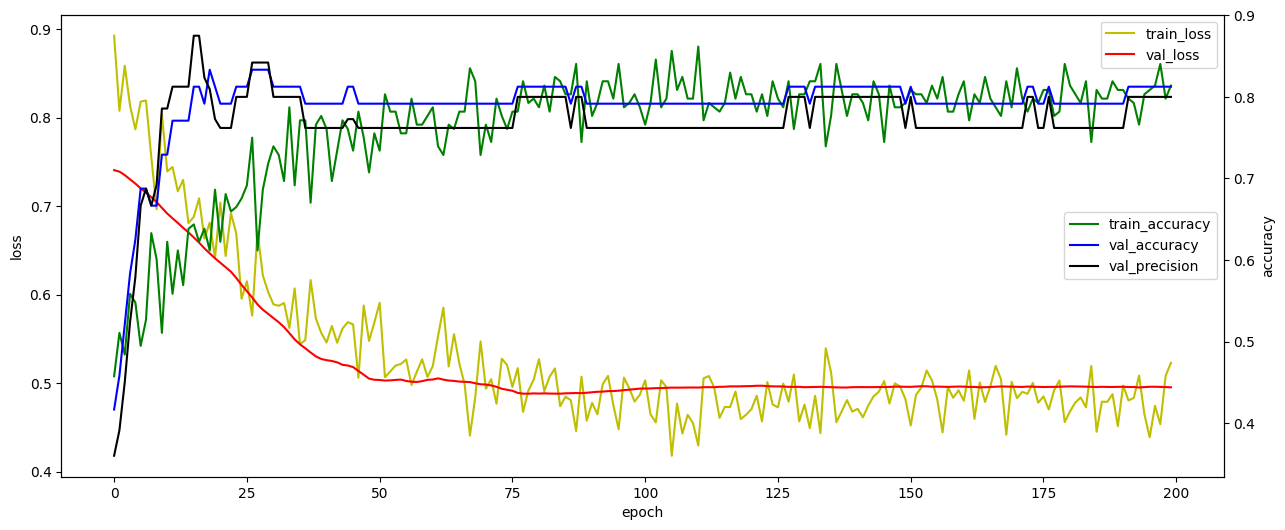

In [138]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
#acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')
acc_ax.plot(hist.history['val_precision'],'k',label='val_precision')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

In [139]:
# 예측값
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

2/2 [==============================] - 0s 5ms/step


array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [140]:
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0,27,5
1,22,6


In [141]:
confusion_matrix(y_test,y_hat)

array([[27,  5],
       [22,  6]], dtype=int64)

## 4. 모델사용

In [ ]:
model.save('model/06.h5')
save_model(model,'model/06.h5')
model2 = load_model('model/06.h5')

In [ ]:
data =[[ 63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3,3 ,0 ,6 ],
      [ 67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3,3]]
input_data

In [143]:
X[:2]

array([[ 63. ,   1. ,   1. , 145. , 233. ,   1. ,   2. , 150. ,   0. ,
          2.3,   3. ,   0. ,   6. ],
       [ 67. ,   1. ,   4. , 160. , 286. ,   0. ,   0. , 108. ,   1. ,
          1.5,   2. ,   3. ,   3. ]])